## Preamble

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

from cpymad.madx import Madx

# Comment out the following lines if plotting cells give an error
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from plot_settings import setPlotSettings
setPlotSettings(font=True)

## Case 1 -- command block A

In [7]:
madx1 = Madx(stdout=False)
madx1.input(f'''
    beam, particle = electron, pc=3.0;
    // Geometry
    THETA    = 0.01;
    L_CORE   = 2.0;
    L_D      = 0.5;
    L_DIPOLE = 2.0;
    
    // Drifts
    D:      DRIFT, L = L_D;
    D_CORE: DRIFT, L = L_CORE;
    
    // Bend
    DIPOLE: SBEND, L = L_DIPOLE, ANGLE = THETA;
    
    // Quad strengths
    K_CORE = 1.2955;
    KD     = 1.0;
    KF     = 1.9;
    
    // Quadrupoles
    Q_CORE: QUADRUPOLE, L = 0.5,  K1 =  K_CORE;
    QD:     QUADRUPOLE, L = 0.5,  K1 = -KD;
    QF:     QUADRUPOLE, L = 0.25, K1 =  KF;
    
    // Beamlines
    CORE: LINE = (DIPOLE, D_CORE, Q_CORE, D_CORE, DIPOLE);
    DBA:  LINE = (QF,D,QD,D, CORE, D,QD,D,QF);
    
    // A) Propagate initial betas through CORE beamline
    use, sequence = core;
    select, flag=twiss, column=name,s,betx,bety,alfx,alfy,dx,dpx;
    twiss, save, betx =  1.0, bety =  1.0, dx = 0.0, dpx = 0.0, file = dba.twi;
    ! twiss, save, betx = 10.0, bety = 10.0, dx = 0.0, dpx = 0.0, file = dba.twi;
    plot, haxis=s, vaxis1=betx,bety, vaxis2=dx, vmax=200,0.04, colour=100,file=dba;
    ''')
twiss1 = madx1.table.twiss

In [8]:
print('Dispersion:')
print(twiss1.dx[-1])
print('Slope:')
print(twiss1.dpx[-1])

Dispersion:
9.962996466958071e-05
Slope:
2.3400936132735375e-05


The quadrupole strength (K_CORE) that makes the dispersion and slope zero is $\boxed{1.2955}$.

The initial and final values of the beta function do not affect this value.

In [9]:
############## say more on why ##############

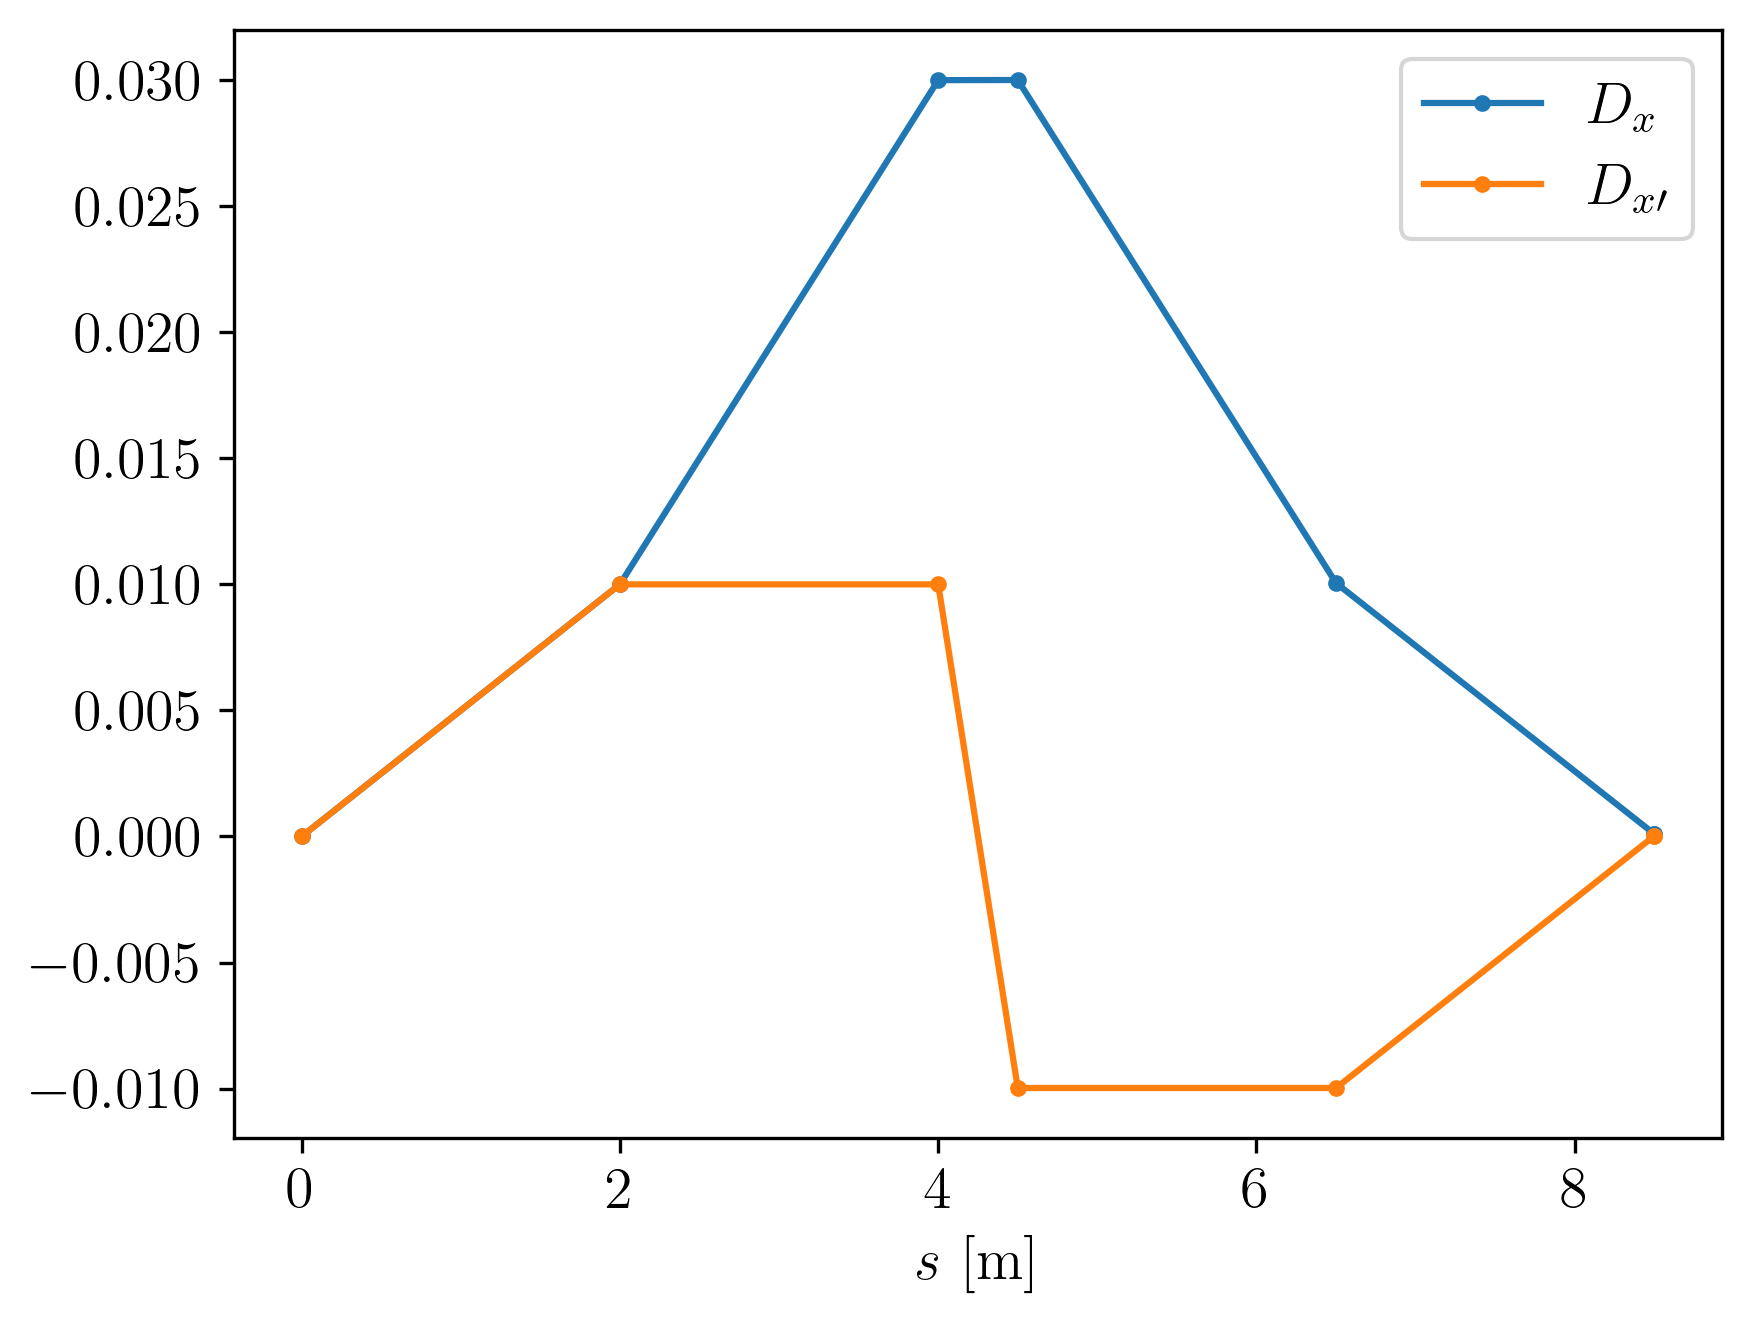

In [23]:
plt.plot(twiss1.s,twiss1.dx,'.-',label='$D_x$')
plt.plot(twiss1.s,twiss1.dpx,'.-',label='$D_{x\prime{}}$')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

## Case 2 -- command block B

In [16]:
madx2 = Madx(stdout=False)
madx2.input(f'''
    beam, particle = electron, pc=3.0;
    // Geometry
    THETA    = 0.01;
    L_CORE   = 2.0;
    L_D      = 0.5;
    L_DIPOLE = 2.0;
    
    // Drifts
    D:      DRIFT, L = L_D;
    D_CORE: DRIFT, L = L_CORE;
    
    // Bend
    DIPOLE: SBEND, L = L_DIPOLE, ANGLE = THETA;
    
    // Quad strengths
    K_CORE = 1.2955;
    KD     = 1.0;
    KF     = 1.9;
    
    // Quadrupoles
    Q_CORE: QUADRUPOLE, L = 0.5,  K1 =  K_CORE;
    QD:     QUADRUPOLE, L = 0.5,  K1 = -KD;
    QF:     QUADRUPOLE, L = 0.25, K1 =  KF;
    
    // Beamlines
    CORE: LINE = (DIPOLE, D_CORE, Q_CORE, D_CORE, DIPOLE);
    DBA:  LINE = (QF,D,QD,D, CORE, D,QD,D,QF);
    
    // B) Attempt a periodic solution for CORE
    use, sequence = core;
    select, flag=twiss, column=name,s,betx,bety,alfx,alfy,dx,dpx;
    match, sequence = core;
    twiss, save, file = dba.twi;
    plot, haxis=s, vaxis1=betx,bety, vaxis2=dx, vmax=200,0.04, colour=100,interpolate,file=dba;
    stop;
    ''')
twiss2 = madx2.table.twiss

++++++ Error: seterrorflag : Errorcode: 1   Reported from pro_twiss:
++++++ Error: seterrorflag : Description: TWISS failed
++++++ Error: seterrorflag : Errorcode: 1   Reported from pro_twiss:
++++++ Error: seterrorflag : Description: TWISS failed


MAD-X failed because it is **not** possible for a system like this to be periodic in $\beta_x$, $\beta_y$, and $D_x$.

## Case 3 -- command block C

### At (KD,KF) = (1.0,1.9):

In [24]:
madx3 = Madx(stdout=False)
madx3.input(f'''
    beam, particle = electron, pc=3.0;
    // Geometry
    THETA    = 0.01;
    L_CORE   = 2.0;
    L_D      = 0.5;
    L_DIPOLE = 2.0;
    
    // Drifts
    D:      DRIFT, L = L_D;
    D_CORE: DRIFT, L = L_CORE;
    
    // Bend
    DIPOLE: SBEND, L = L_DIPOLE, ANGLE = THETA;
    
    // Quad strengths
    K_CORE = 1.2955;
    KD     = 1.0;
    KF     = 1.9;
    
    // Quadrupoles
    Q_CORE: QUADRUPOLE, L = 0.5,  K1 =  K_CORE;
    QD:     QUADRUPOLE, L = 0.5,  K1 = -KD;
    QF:     QUADRUPOLE, L = 0.25, K1 =  KF;
    
    // Beamlines
    CORE: LINE = (DIPOLE, D_CORE, Q_CORE, D_CORE, DIPOLE);
    DBA:  LINE = (QF,D,QD,D, CORE, D,QD,D,QF);
    
    // C) Attempt a periodic solution for DBA 
    use, sequence = dba;
    select, flag=twiss, column=name,s,betx,bety,alfx,alfy,dx,dpx;
    match, sequence = dba;
    twiss, save, file = dba.twi;
    plot, haxis=s, vaxis1=betx,bety, vaxis2=dx, vmax=40,0.05, colour=100,interpolate,file=dba;
    stop;
    ''')
twiss3 = madx3.table.twiss

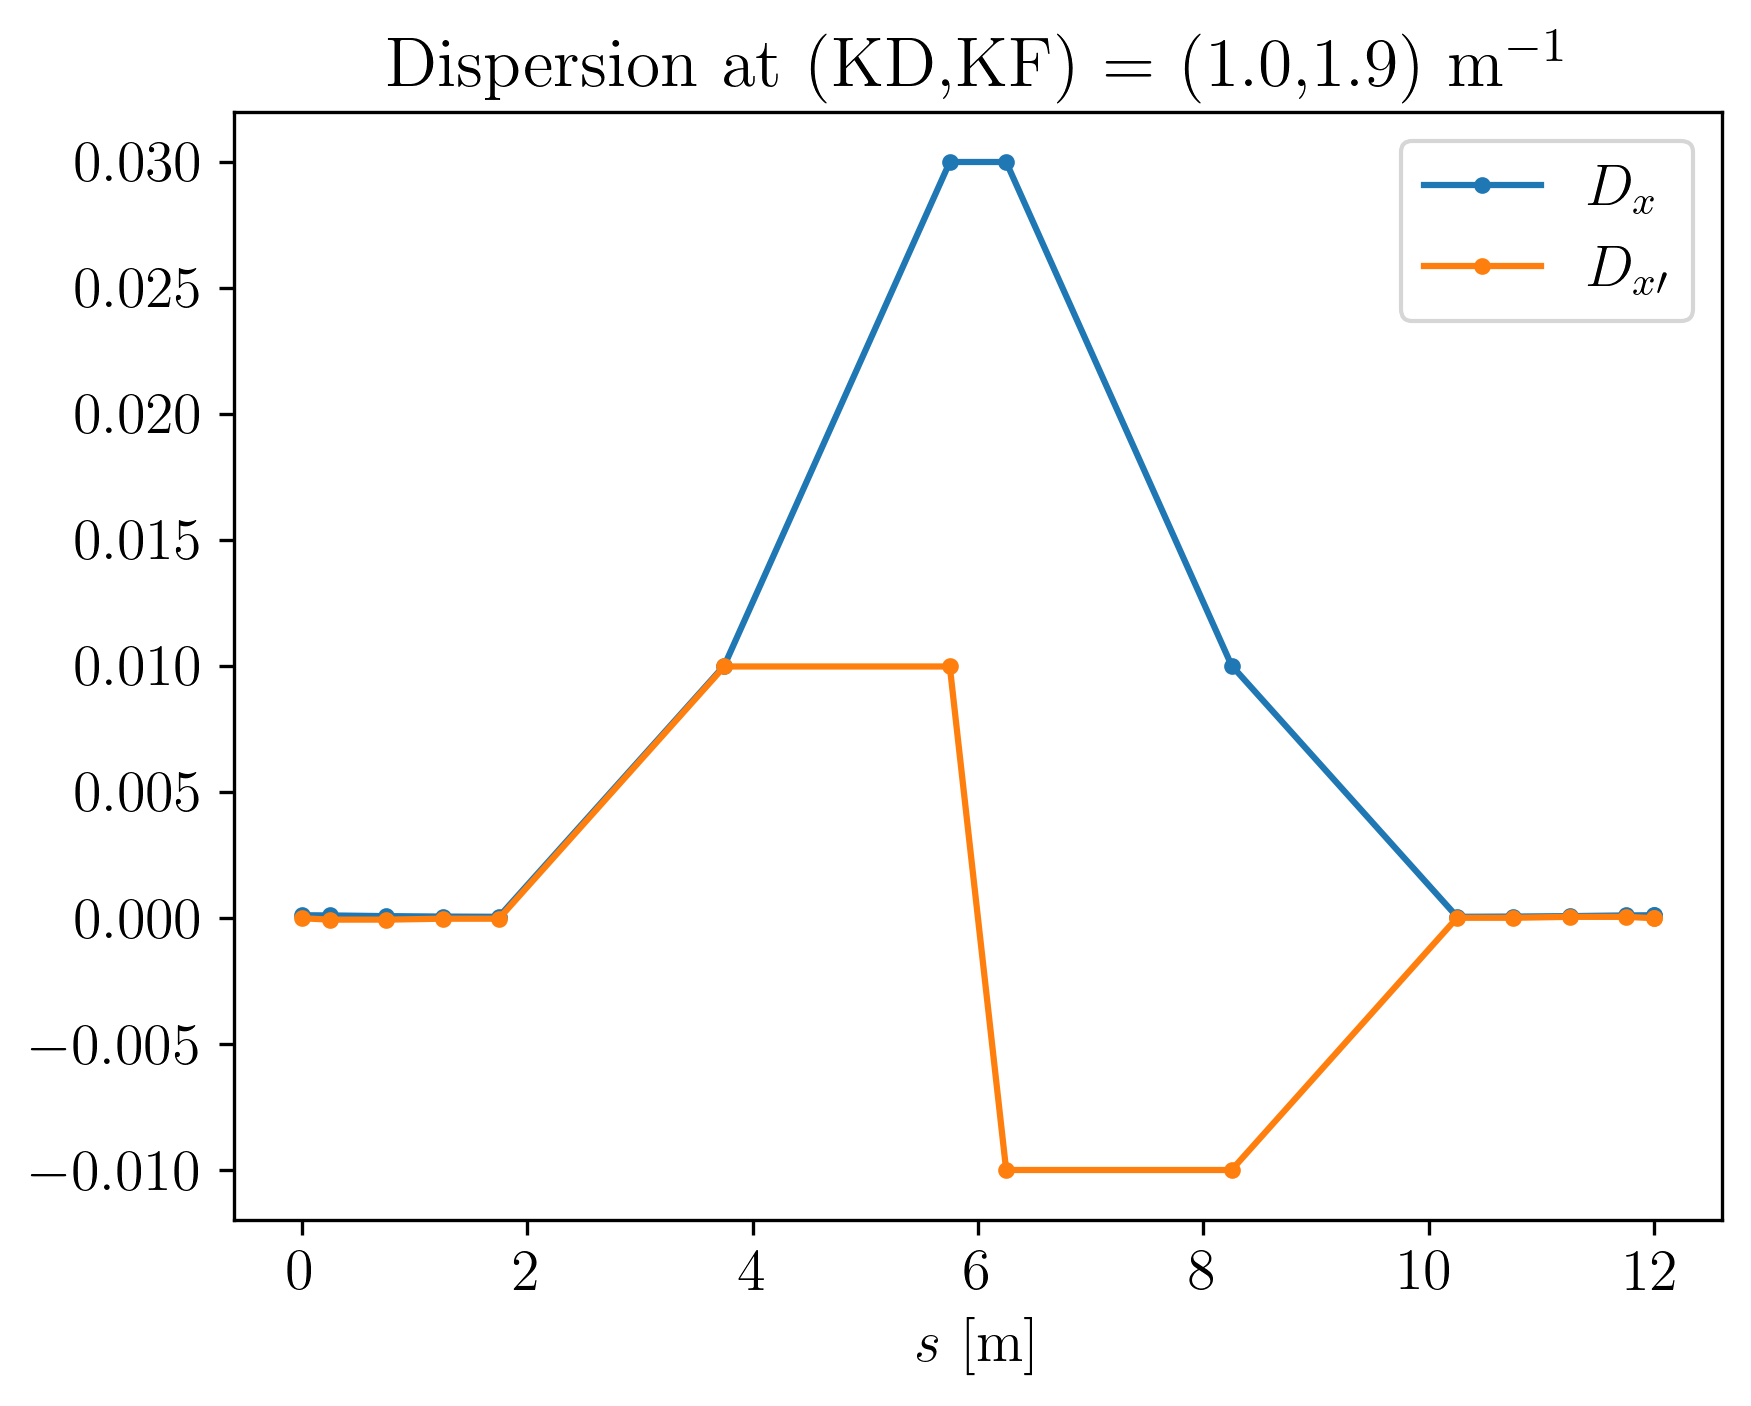

In [35]:
plt.title('Dispersion at (KD,KF) = (1.0,1.9) m$^{-1}$')
plt.plot(twiss3.s,twiss3.dx,'.-',label='$D_x$')
plt.plot(twiss3.s,twiss3.dpx,'.-',label='$D_{x\prime{}}$')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

In [46]:
print('Min and max dispersion:')
print(np.min(twiss3.dx))
print(np.max(twiss3.dx))

Min and max dispersion:
5.652345310208813e-05
0.029982362883559967


In [47]:
print('Min and max slope:')
print(np.min(twiss3.dpx))
print(np.max(twiss3.dpx))

Min and max slope:
-0.009981396994941867
0.009981396994941862


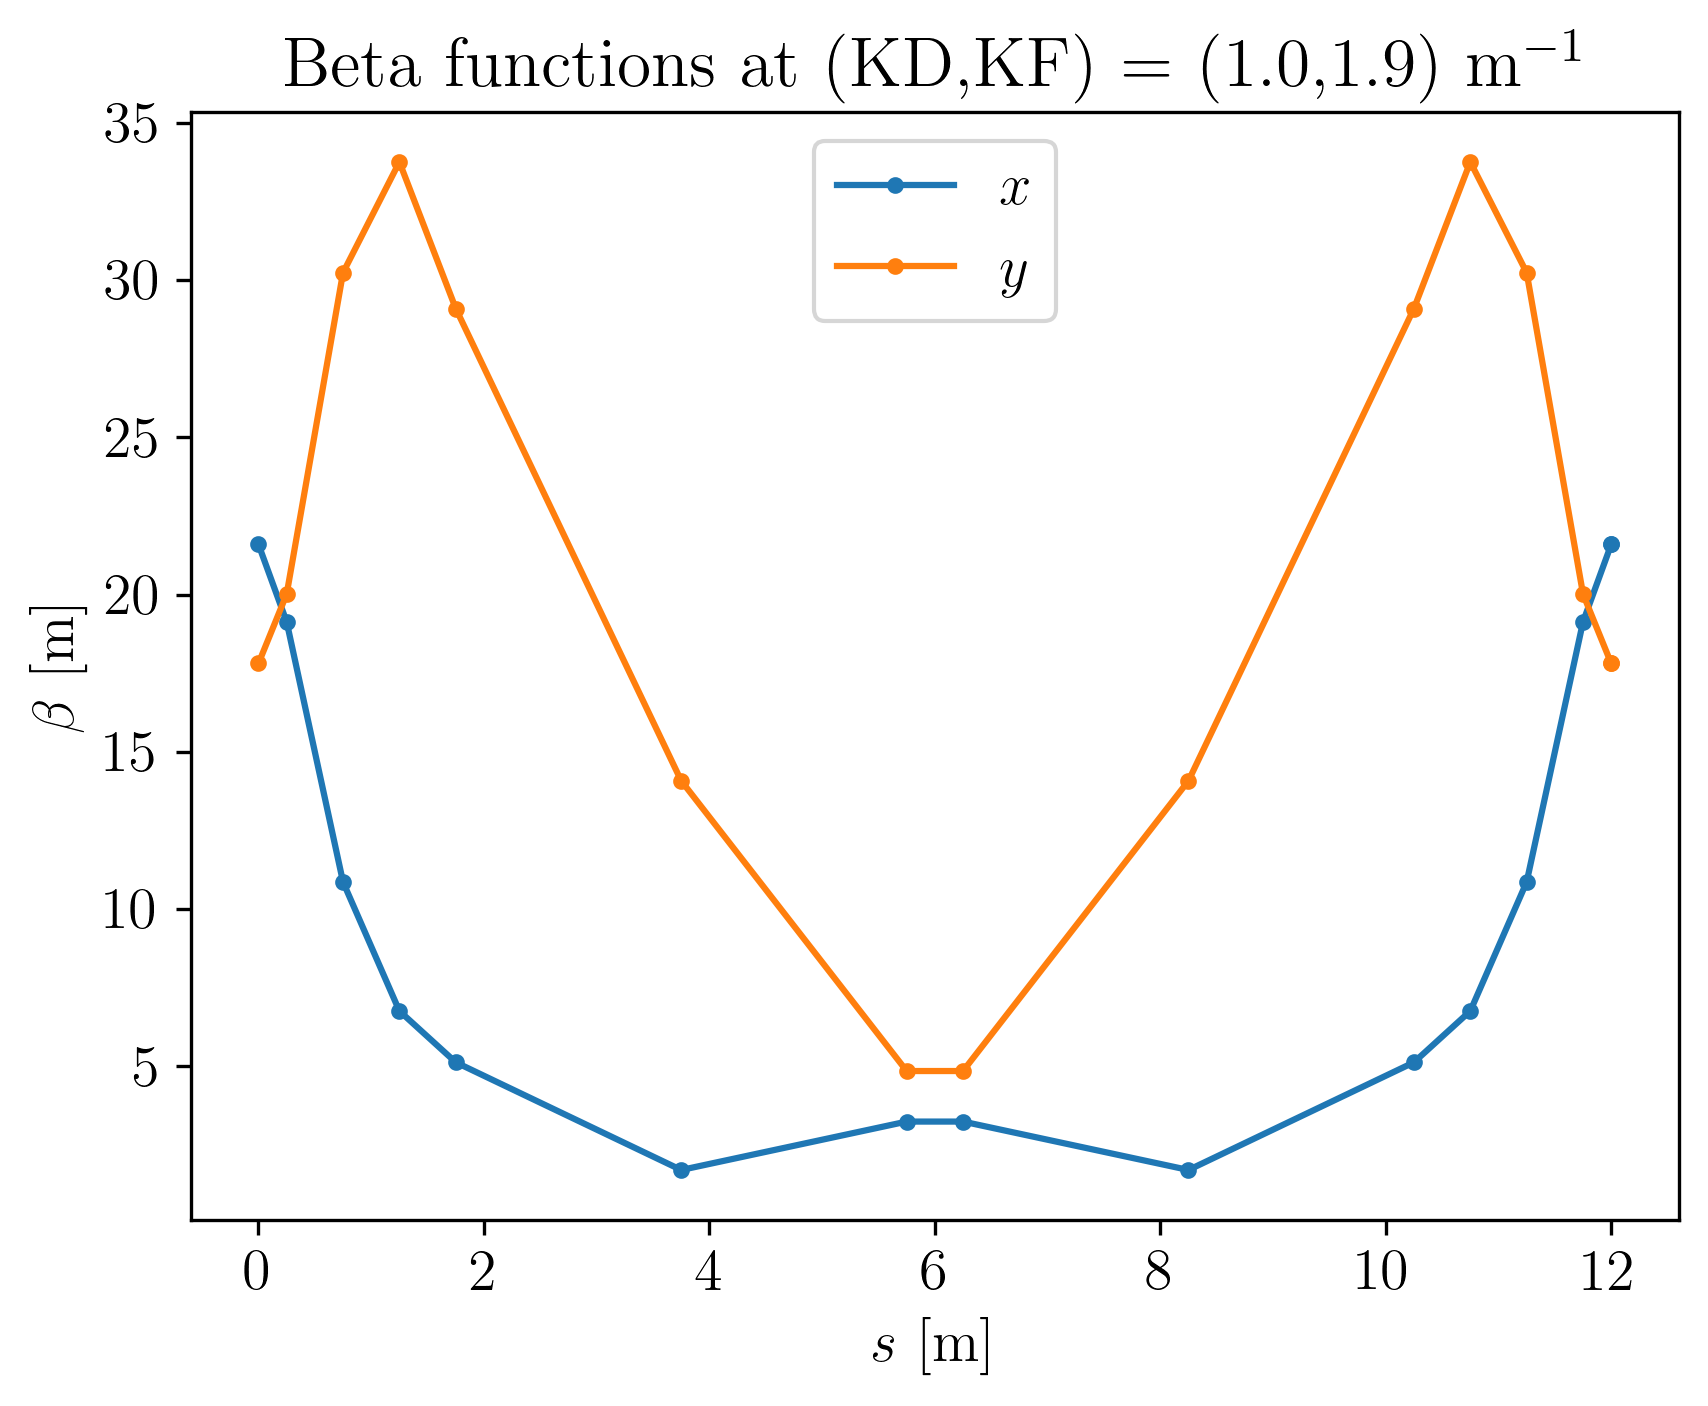

In [37]:
plt.title('Beta functions at (KD,KF) = (1.0,1.9) m$^{-1}$')
plt.plot(twiss3.s,twiss3.betx,'.-',label='$x$')
plt.plot(twiss3.s,twiss3.bety,'.-',label='$y$')
plt.ylabel(r'$\beta$ [m]')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

In [43]:
print('Min and max beta x:')
print(np.min(twiss3.betx))
print(np.max(twiss3.betx))

Min and max beta x:
1.7010403608557345
21.593178597471827


In [44]:
print('Min and max beta y:')
print(np.min(twiss3.bety))
print(np.max(twiss3.bety))

Min and max beta y:
4.848035575803156
33.753777225838355


### Exploring (KD,KF) space:

In [127]:
madx4 = Madx(stdout=False)
madx4.input(f'''
    beam, particle = electron, pc=3.0;
    // Geometry
    THETA    = 0.01;
    L_CORE   = 2.0;
    L_D      = 0.5;
    L_DIPOLE = 2.0;
    
    // Drifts
    D:      DRIFT, L = L_D;
    D_CORE: DRIFT, L = L_CORE;
    
    // Bend
    DIPOLE: SBEND, L = L_DIPOLE, ANGLE = THETA;
    
    // Quad strengths
    K_CORE = 1.2955;
    KD     = 1.0;
    KF     = 2.01;
    
    // Quadrupoles
    Q_CORE: QUADRUPOLE, L = 0.5,  K1 =  K_CORE;
    QD:     QUADRUPOLE, L = 0.5,  K1 = -KD;
    QF:     QUADRUPOLE, L = 0.25, K1 =  KF;
    
    // Beamlines
    CORE: LINE = (DIPOLE, D_CORE, Q_CORE, D_CORE, DIPOLE);
    DBA:  LINE = (QF,D,QD,D, CORE, D,QD,D,QF);
    
    // C) Attempt a periodic solution for DBA 
    use, sequence = dba;
    select, flag=twiss, column=name,s,betx,bety,alfx,alfy,dx,dpx;
    match, sequence = dba;
    twiss, save, file = dba.twi;
    plot, haxis=s, vaxis1=betx,bety, vaxis2=dx, vmax=40,0.05, colour=100,interpolate,file=dba;
    stop;
    ''')
twiss4 = madx4.table.twiss

++++++ Error: seterrorflag : Errorcode: 1   Reported from pro_twiss:
++++++ Error: seterrorflag : Description: TWISS failed
++++++ Error: seterrorflag : Errorcode: 1   Reported from pro_twiss:
++++++ Error: seterrorflag : Description: TWISS failed


with KF = 1.9 (initial):

KD = 1.12 throws an error --> max around $\boxed{1.11}$

KD = 0.97 throws an error --> min around $\boxed{0.98}$

with KD = 1.0 (initial):

KF = 1.80 throws an error --> min around $\boxed{1.81}$

KF = 2.01 throws an error --> max around $\boxed{2.00}$

In [ ]:
KD_vals = np.arange(0.98,1.11,0.01)
KF_vals = np.arange(1.81,2.00,0.01)

In [119]:
print(len(KD_vals))
print(len(KF_vals))

14
19


In [120]:
gridX = np.arange(0,2,0.01)
gridY = np.arange(0,2,0.01)
vals = np.zeros((len(gridX),len(gridY)))
valsX = []
valsY = []
for nx in range(len(gridX)):
    x = gridX[nx]
    for ny in range(len(gridY)):
        y = gridY[ny]
        if x in KD_vals and y in KF_vals:
            vals[nx][ny] = 1

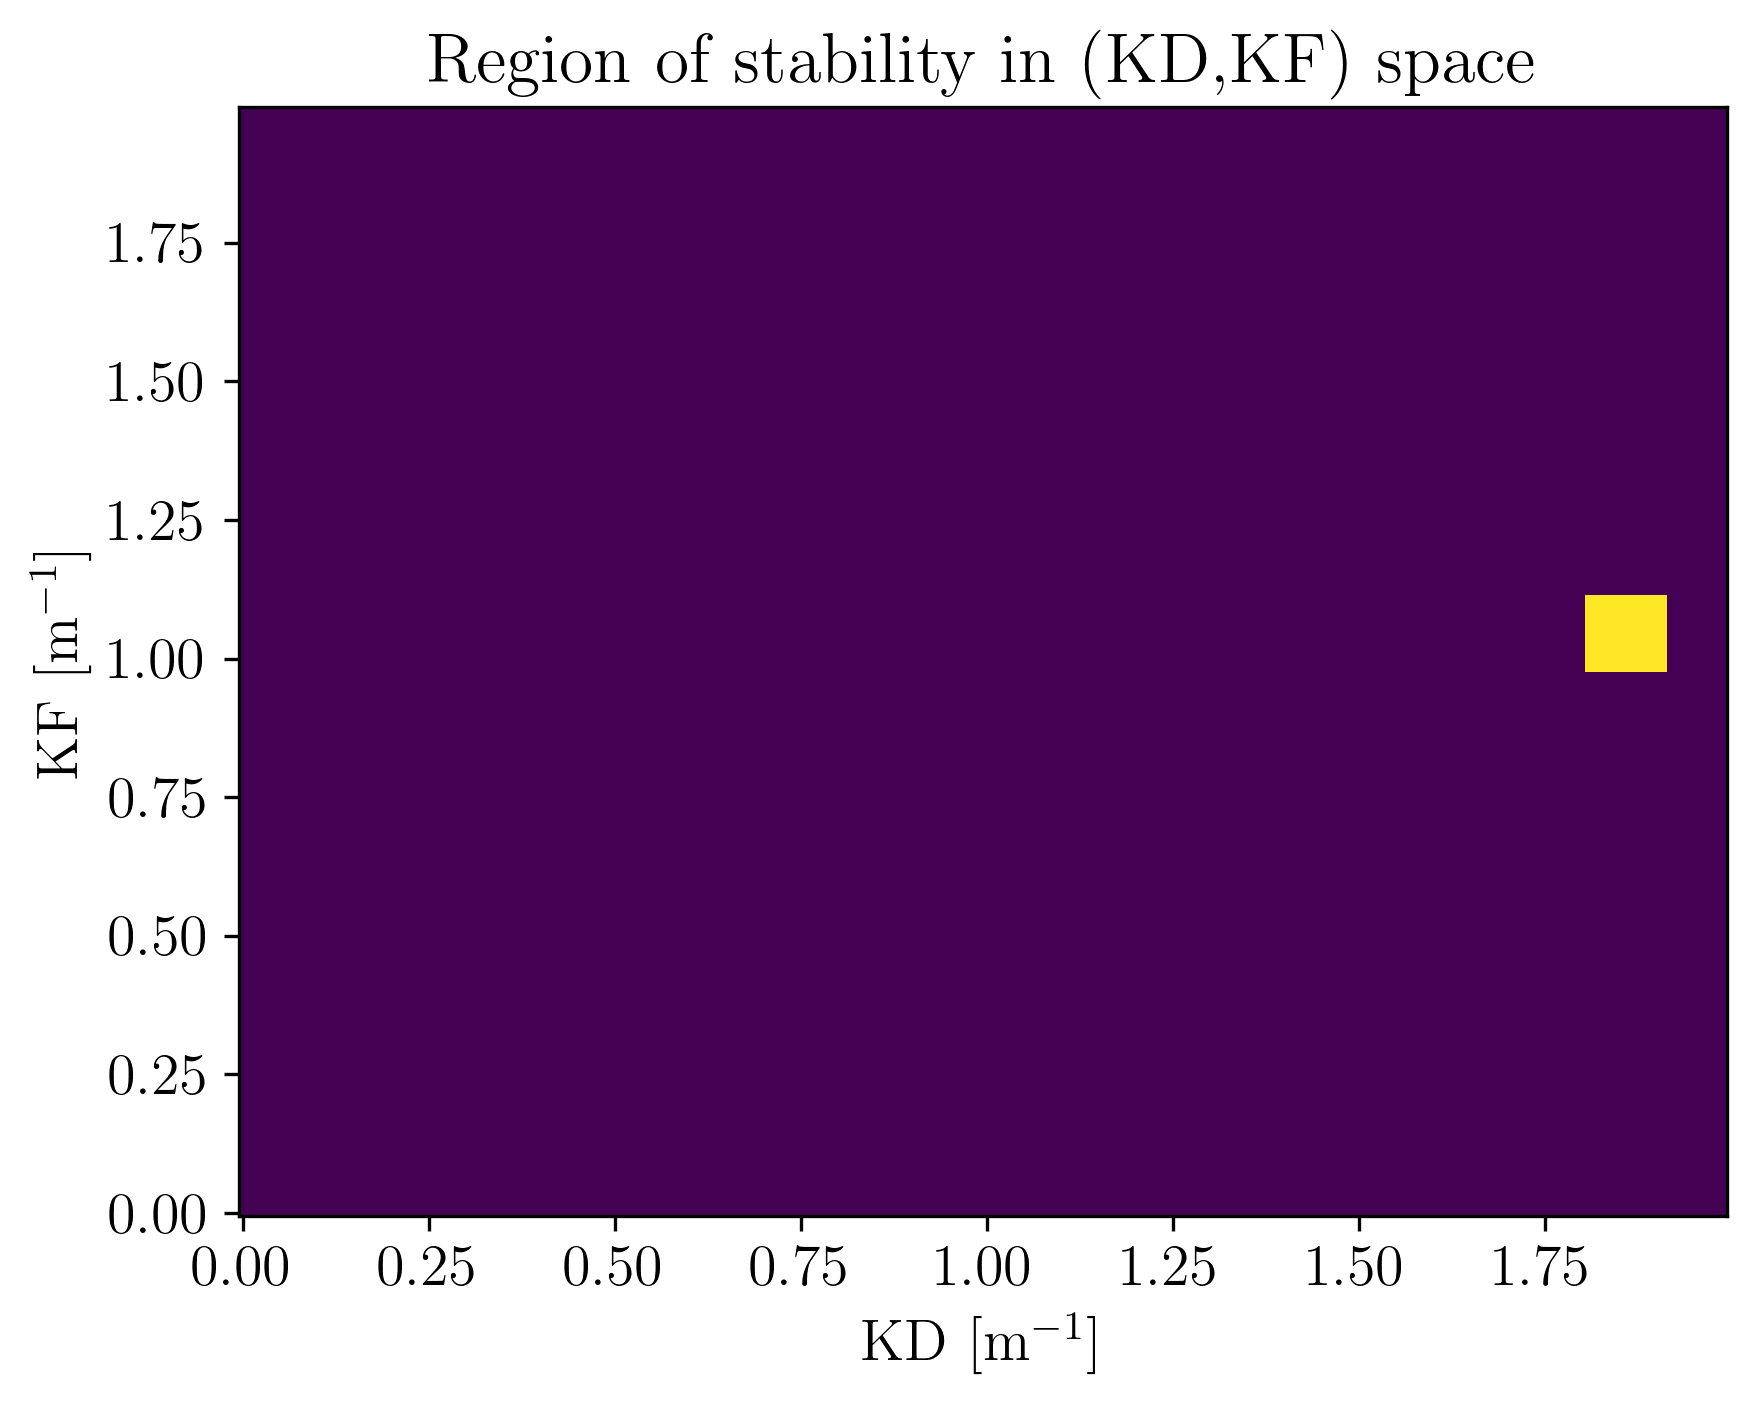

In [124]:
fig, ax = plt.subplots()
ax.pcolormesh(gridX, gridY, vals)
plt.xlabel('KD [m$^{-1}$]')
plt.ylabel('KF [m$^{-1}$]')
plt.title('Region of stability in (KD,KF) space')
plt.show()

### Observations:

- There is only a very small region of (KD,KF) space that is stable, as indicated by the yellow region in the plot above.

- This region of stability is rectangular, indicating the KF parameter space is slightly more robust than KD.

To expand the region of stability, one could adjust K_CORE as well, enabling the exploration of 3D (KD,KF,K_CORE) space to find more regions of stability. A quick change of K_CORE made some of the previously unstable values of KF and KD viable, supporting this hypothesis.